# How do the residuals look like?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# data
#from CleanDataPreliminary import *
from Preliminary_Predictions_S2 import *
#from DEL_tensorboard_prep import *

Saved to: runs/xgb_20260213-152408


In [2]:
errors = y_val - val_pred

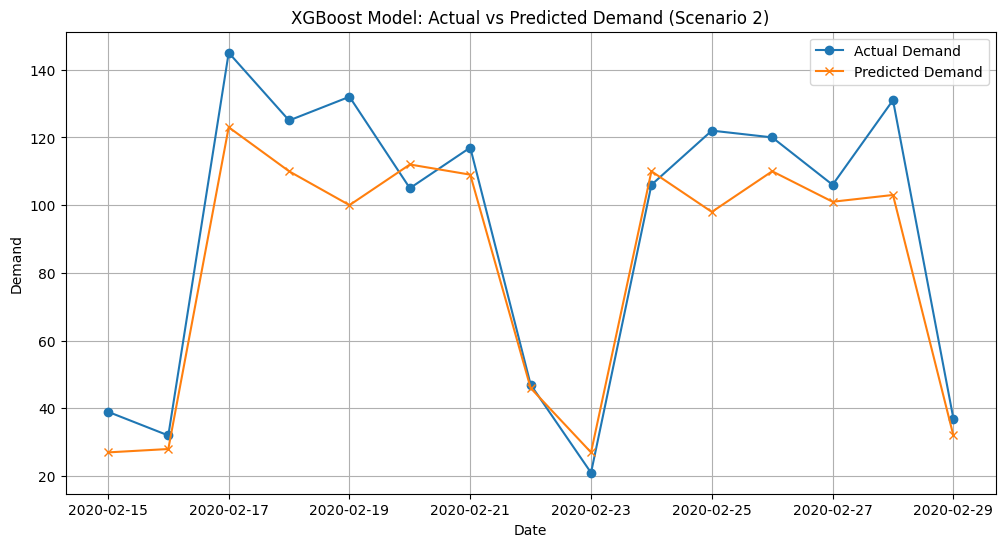

In [3]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg['date'], S2_daily_agg['n'], label='Actual Demand', marker='o')
plt.plot(S2_daily_agg['date'], S2_daily_agg['predicted'], label='Predicted Demand', marker='x')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('XGBoost Model: Actual vs Predicted Demand (Scenario 2)')
plt.legend()
plt.grid()
plt.show()

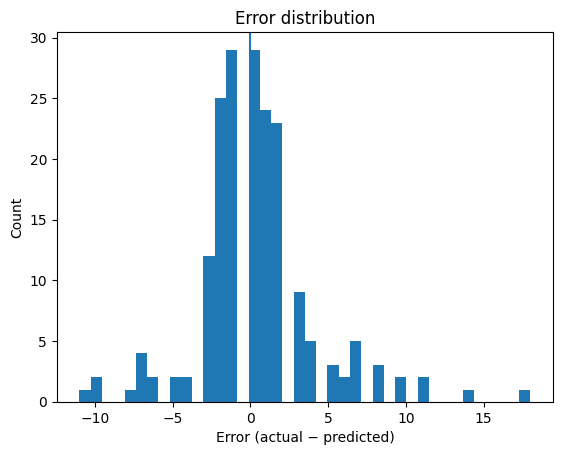

In [4]:
plt.hist(errors, bins=40)
plt.axvline(0)
plt.xlabel("Error (actual − predicted)")
plt.ylabel("Count")
plt.title("Error distribution")
plt.show()


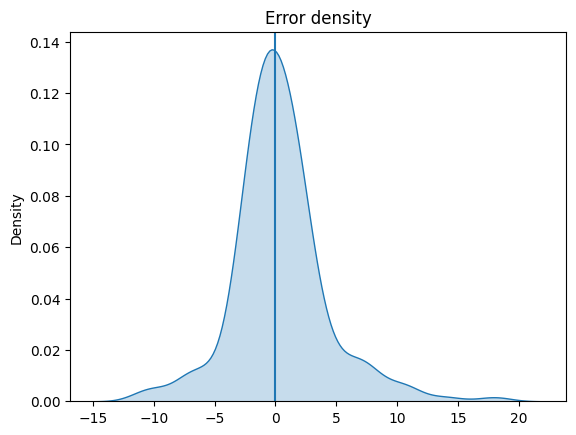

In [5]:
sns.kdeplot(errors, fill=True)
plt.axvline(0)
plt.title("Error density")
plt.show()


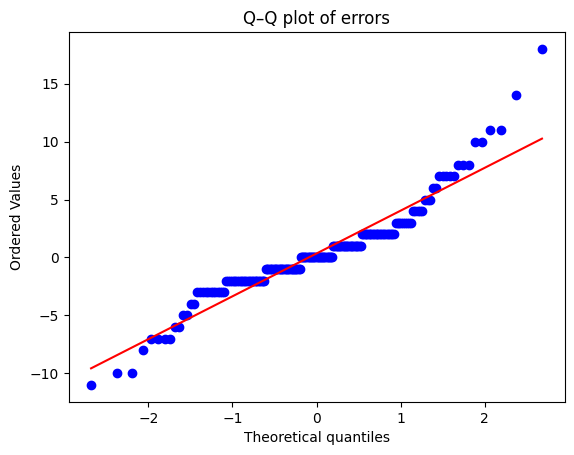

In [6]:
stats.probplot(errors, dist="norm", plot=plt)
plt.title("Q–Q plot of errors")
plt.show()

# Different CI's

## Baseline (Residual-based: Empirical)
As I cannot assume the errors are normal (based on the above plots), we make the baseline emperical

In [7]:
from CI_baseline import *

        date    n  predicted  lower_90  upper_90
0 2020-02-15   39       27.0       7.4      62.0
1 2020-02-16   32       28.0       5.4      77.0
2 2020-02-17  145      123.0      62.0     228.0
3 2020-02-18  125      110.0      51.6     215.0
4 2020-02-19  132      100.0      48.0     184.0


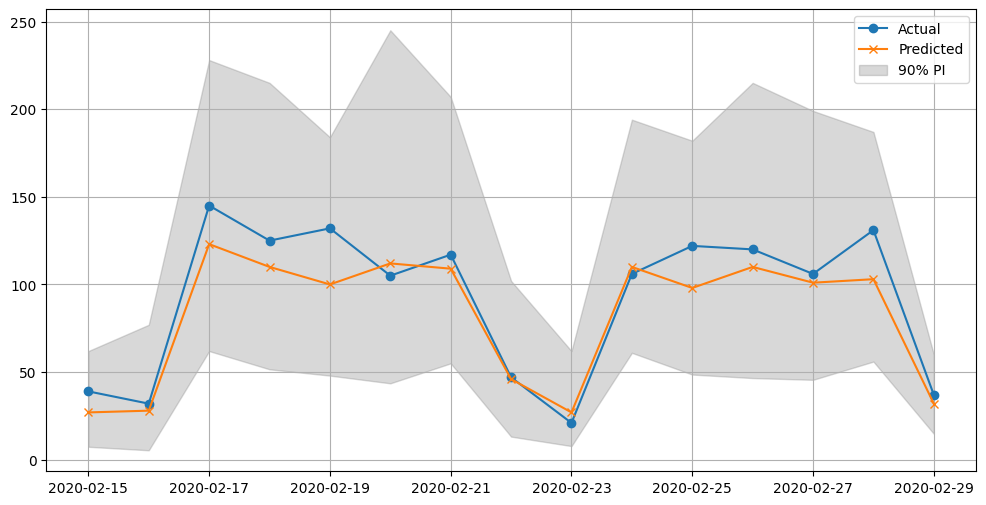

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['n'], marker='o', label='Actual')
plt.plot(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['predicted'], marker='x', label='Predicted')
plt.fill_between(S2_daily_agg_baseline['date'], S2_daily_agg_baseline['lower_90'], S2_daily_agg_baseline['upper_90'], alpha=0.3, color="gray", label='90% PI')
plt.legend()
plt.grid()
plt.show()


In [9]:
coverage_baseline = np.mean(
    (test_daily['n'] >= S2_daily_agg_baseline['lower_90']) & (test_daily['n'] <= S2_daily_agg_baseline['upper_90'])
)
print("90% interval coverage:", coverage_baseline)

width_baseline = np.mean(S2_daily_agg_baseline['upper_90'] - S2_daily_agg_baseline['lower_90'])
print("Quantile XGB avg width:", width_baseline)

90% interval coverage: 1.0
Quantile XGB avg width: 123.49333333333335


## XGB Quantile regression

In [10]:
from CI_XGBQuantile import *

        date    n  predicted  lower_90  upper_90
0 2020-02-15   39       26.0       8.0      57.0
1 2020-02-16   32       30.0      10.0      66.0
2 2020-02-17  145      117.0      53.0     203.0
3 2020-02-18  125      112.0      44.0     191.0
4 2020-02-19  132      100.0      40.0     174.0


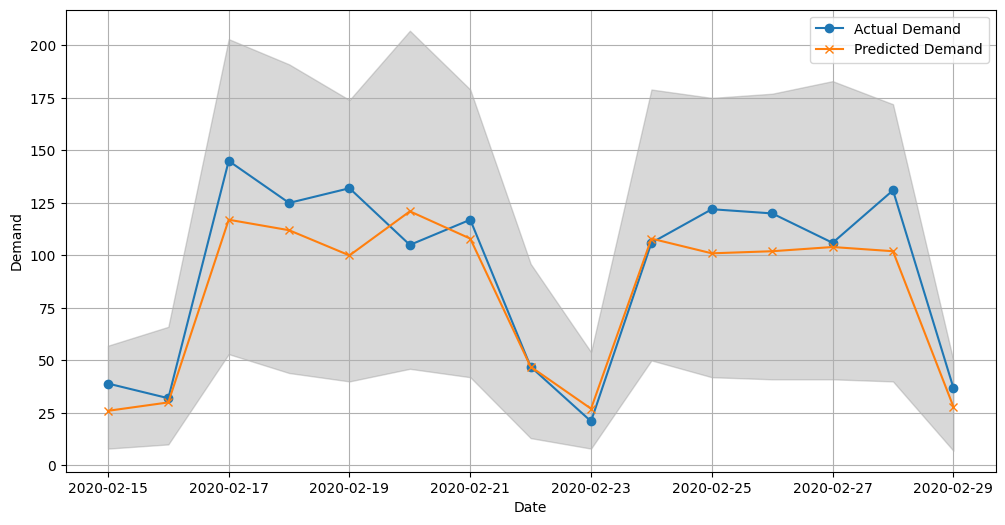

In [11]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg["date"], S2_daily_agg["n"], label="Actual Demand", marker="o")
plt.plot(S2_daily_agg["date"], S2_daily_agg["predicted"], label="Predicted Demand", marker="x")
plt.fill_between(
    S2_daily_agg["date"],
    S2_daily_agg["lower_90"],
    S2_daily_agg["upper_90"],
    color="gray",
    alpha=0.3
)
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid()
plt.show()

In [12]:
coverage_xgb = np.mean(
    (test_daily['n'] >= S2_daily_agg['lower_90']) & (test_daily['n'] <= S2_daily_agg['upper_90'])
)
print("90% interval coverage:", coverage_xgb)


width_xgb = np.mean(S2_daily_agg['upper_90'] - S2_daily_agg['lower_90'])
print("Quantile XGB avg width:", width_xgb)

90% interval coverage: 1.0
Quantile XGB avg width: 111.86667


## temp 
explain the residuals

In [ ]:
# run tensorBoard.py in terminal as
#print(f"python tensorBoard.py runs/{run_dir}")

python tensorBoard.py runs/runs/xgb_20260213-152408


## Banwidth simple

In [14]:
from CI_banwidth_simple import *

        date    n  predicted       lower       upper
0 2020-02-15   39       27.0   18.055728   35.944272
1 2020-02-16   32       28.0   17.416995   38.583005
2 2020-02-17  145      123.0  107.508067  138.491933
3 2020-02-18  125      110.0   94.508067  125.491933
4 2020-02-19  132      100.0   86.143594  113.856406


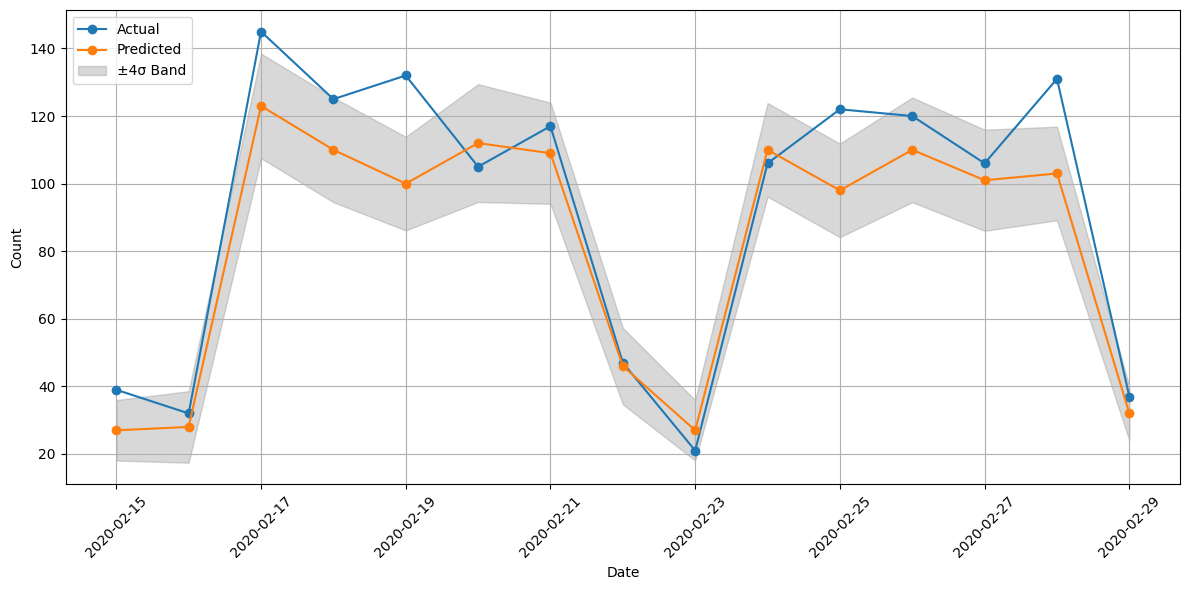

In [15]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["n"], label="Actual", marker="o")
plt.plot(daily["date"], daily["predicted"], label="Predicted", marker="o")
plt.fill_between(daily["date"], daily["lower"], daily["upper"], color="gray", alpha=0.3, label="±4σ Band")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [16]:
# coverage
coverage_bandwidth_simple = np.mean((daily["n"] >= daily["lower"]) & (daily["n"] <= daily["upper"]))
print(f"Coverage of ±4σ Band: {coverage_bandwidth_simple:.2%}")
# width
daily["bandwidth"] = daily["upper"] - daily["lower"]
width_bandwidth_simple = daily["bandwidth"].mean()
print(f"Average Bandwidth: {width_bandwidth_simple:.2f}")

Coverage of ±4σ Band: 66.67%
Average Bandwidth: 26.27


## Bootstrap

In [ ]:
from CI_bootstrap_rev_cali import *

        date    n  predicted  lower  upper
0 2020-02-15   39       27.0   18.0   48.0
1 2020-02-16   32       28.0   18.0   53.0
2 2020-02-17  145      123.0  111.0  164.0
3 2020-02-18  125      110.0   98.0  151.0
4 2020-02-19  132      100.0   88.0  136.0


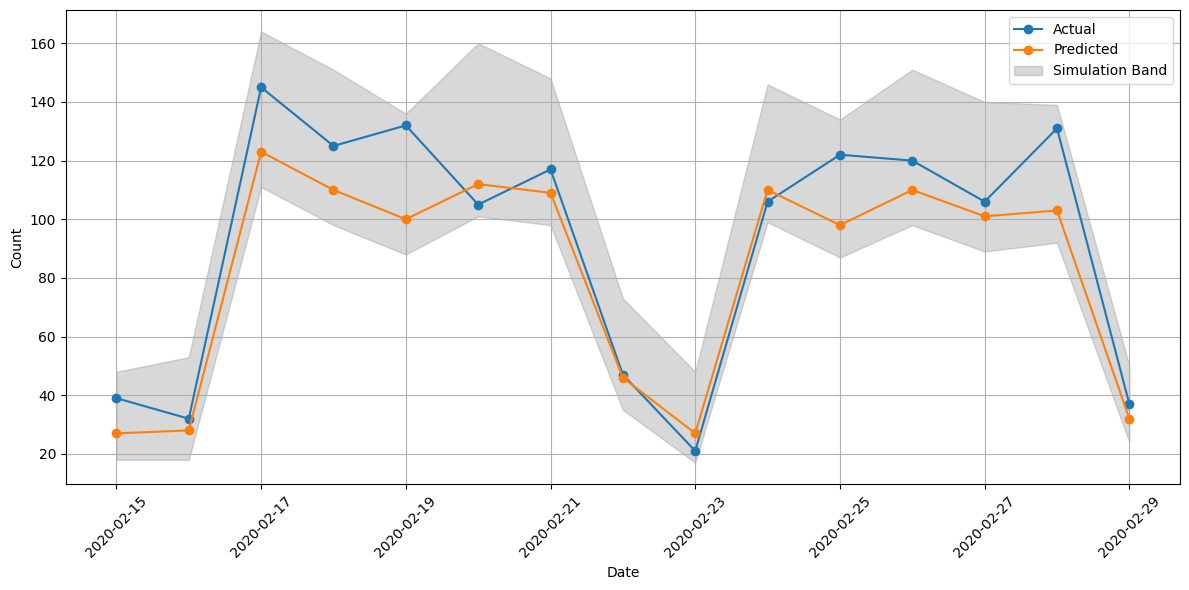

In [18]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["n"], label="Actual", marker="o")
plt.plot(daily["date"], daily["predicted"], label="Predicted", marker="o")
plt.fill_between(daily["date"], daily["lower"], daily["upper"], color="gray", alpha=0.3, label="Simulation Band")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [19]:
# coverage
coverage_bootstrap = np.mean((daily["n"] >= daily["lower"]) & (daily["n"] <= daily["upper"]))
print(f"Coverage of Simulation Band: {coverage_bootstrap:.2%}")
# width
daily["bandwidth"] = daily["upper"] - daily["lower"]
width_bootstrap = daily["bandwidth"].mean()
print(f"Average Bandwidth: {width_bootstrap:.2f}")

Coverage of Simulation Band: 100.00%
Average Bandwidth: 44.54


In [20]:
# Create a dictionary with the methods, coverages, and widths
comparison_data = {
    "Method": [
        "Baseline", 
        "XGB Quantile Regression", 
        "Bandwidth Simple", 
        "Bootstrap"
    ],
    "Coverage": [
        coverage_baseline, 
        coverage_xgb, 
        coverage_bandwidth_simple, 
        coverage_bootstrap
    ],
    "Width": [
        width_baseline, 
        width_xgb, 
        width_bandwidth_simple, 
        width_bootstrap
    ]
}

# Create a DataFrame
comparison_table = pd.DataFrame(comparison_data)

# Display the table
print(comparison_table)



                    Method  Coverage       Width
0                 Baseline  1.000000  123.493333
1  XGB Quantile Regression  1.000000  111.866669
2         Bandwidth Simple  0.666667   26.274072
3                Bootstrap  1.000000   44.536667
